量子生成对抗网络 (Quantum GANs)
================

在本教程中，我们将探索使用量子生成对抗网络(Quantum GANs)来生成手写数字0。我们首先介绍经典GAN的理论，然后拓展到最近文献中提出的一种量子方法。

生成对抗网络(GANs，Generative Adversarial Networks)
================

生成对抗网络(GANs)的目标是生成与训练数据相似的新数据[1]。为了实现这一点，我们同时训练两个神经网络：一个生成器(Generator)和一个判别器(Discriminator)。生成器的任务是创造出与真实训练数据相似的假数据，而判别器就像一个侦探，试图辨别真假数据。在训练过程中，两个玩家迭代地相互改进。最终，生成器应该能够生成与训练数据非常相似的新数据。

具体来说，训练数据集代表了从某个未知数据分布$P_{data}$中采样得到的样本，而生成器的任务就是试图捕捉这个分布。生成器$G$从某个初始隐变量分布$P_z$开始，将其映射到$P_g = G(P_z)$。理想的解是使得$P_g = P_{data}$。

判别器$D$和生成器$G$在一个2人最小-最大博弈中博弈。判别器试图最大化区分真假数据的概率，而生成器试图最小化同样的概率。这个博弈的价值函数可以概括为：

$$\begin{aligned}

\min_G \max_D V(D,G) &= \mathbb{E}_{\boldsymbol{x}\sim p_{data}}[\log D(\boldsymbol{x})] \\  
    & ~~ + \mathbb{E}_{\boldsymbol{z}\sim p_{\boldsymbol{z}}}[\log(1 - D(G(\boldsymbol{z}))]

\end{aligned}$$

- $\boldsymbol{x}$：真实数据样本
- $\boldsymbol{z}$：隐变量
- $D(\boldsymbol{x})$：判别器将真实数据分类为真的概率 
- $G(\boldsymbol{z})$：假数据
- $D(G(\boldsymbol{z}))$：判别器将假数据分类为真的概率

在实践中，这两个网络是迭代训练的，各自有一个要最小化的损失函数：

$$L_D = -[y \cdot \log(D(x)) + (1-y)\cdot \log(1-D(G(z)))]$$

$$L_G = [(1-y) \cdot \log(1-D(G(z)))]$$

其中$y$是真($y=1$)或假($y=0$)数据的二元标签。在实践中，如果让生成器最大化$\log(D(G(z)))$而不是最小化$\log(1-D(G(z)))$，生成器的训练会更稳定。因此，生成器要最小化的损失函数变为：

$$L_G = -[(1-y) \cdot \log(D(G(z)))]$$ 

量子GAN：分块方法
==============

在本教程中，我们重现了Huang等人提出的一种量子GAN方法[2]：分块方法。该方法使用多个量子生成器，每个子生成器$G^{(i)}$负责构建最终图像的一小块。最终图像通过将所有分块拼接在一起构成，如下图所示。

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/3_7_0001.png" width="60%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>

这种方法的主要优势在于它特别适合可用量子比特数受限的情况。同一个量子设备可以迭代地用于每个子生成器，或者可以在多个设备上并行执行生成器。

模块导入 
=======

In [1]:
# 导入库
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Pytorch的导入
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# DeepQuantum的导入
import deepquantum as dq

# 设置随机种子以确保结果可复现
seed = 1024
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

数据
==

如前言中所提到的，我们将使用一个[小型手写数字0数据集](https://archive.ics.uci.edu/ml/datasets/optical+recognition+of+handwritten+digits)。首先，我们需要为这个数据集创建一个自定义的数据加载器。

In [2]:
class DigitsDataset(Dataset):
    """用于手写数字光学识别数据集的Pytorch数据加载器"""

    def __init__(self, csv_file, label=0, transform=None):
        """
        参数:
            csv_file (字符串): 注释的csv文件路径.
            transform (可调用, 可选): 可以在样本上应用的可选转换.
        """
        self.csv_file = csv_file
        self.transform = transform
        self.df = self._filter_by_label(label)

    def _filter_by_label(self, label):
        # 使用pandas返回只有零的数据框
        df = pd.read_csv(self.csv_file)
        df = df[df.iloc[:, -1] == label]
        return df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        image = self.df.iloc[idx, :-1].values / 16
        image = image.astype(np.float32).reshape(8, 8)

        if self.transform:
            image = self.transform(image)

        # 返回图像和标签
        return image, 0


接下来我们定义一些变量并创建数据加载器实例。 

In [3]:
image_size = 8  # 图片尺寸
batch_size = 1

transform = transforms.Compose([transforms.ToTensor()])
dataset = DigitsDataset(csv_file="./data/optdigits.tra", transform=transform)
dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True, drop_last=True
)

让我们可视化一些数据。

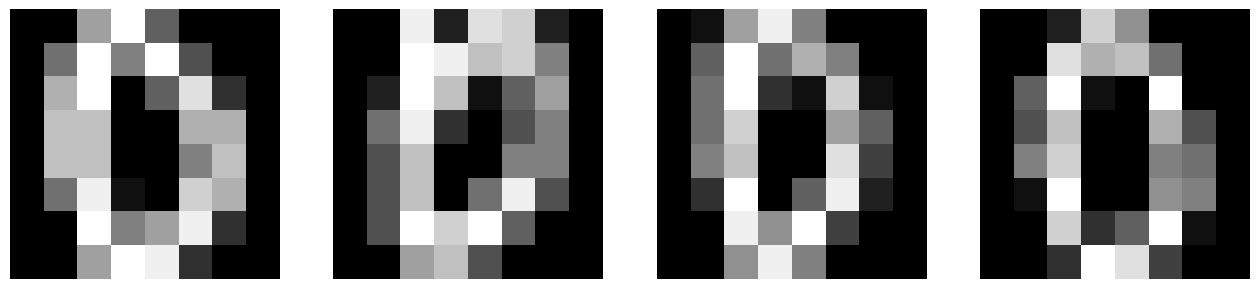

In [4]:
plt.figure(figsize=(16,8))

for i in range(4):
    image = dataset[i][0].reshape(image_size,image_size)
    plt.subplot(1,4,i+1)
    plt.axis('off')
    plt.imshow(image.numpy(), cmap='gray')
    
plt.show()

实现判别器
========

对于判别器，我们使用一个有两个隐藏层的全连接神经网络。一个输出表示输入被分类为真的概率。

In [5]:
class Discriminator(nn.Module):
    """全连接的经典判别器"""

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            # 输入到第一隐藏层 (num_input_features -> 64)
            nn.Linear(image_size * image_size, 64),
            nn.LeakyReLU(0.2),
            # 第一隐藏层 (64 -> 16)
            nn.Linear(64, 16),
            nn.LeakyReLU(0.2),
            # 第二隐藏层 (16 -> output)
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x.view(x.size(0), -1))


<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/3_7_0002.png" width="60%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>

实现生成器
========

每个子生成器$G^{(i)}$共享如下所示的相同线路架构。整个量子生成器由$N_G$个子生成器组成，每个子生成器包含$N$个量子比特。从隐变量输入到图像输出的过程可以分为四个不同的部分：编码量子态、参数化层、非线性变换和后处理。为了简化讨论，下面的讨论都是指训练过程中的单次迭代。

**1) 编码量子态**

从均匀分布$[0,\pi/2)$中采样一个隐变量$\boldsymbol{z}\in\mathbb{R}^N$。所有子生成器接收相同的隐变量，然后使用RY门进行量子态编码。

**2) 参数化层**

参数化层由参数化RY门和受控Z门组成。这一层总共重复$D$次。

**3) 非线性变换** 

在线路模型中，量子门是幺正的，根据定义，它们对量子态进行线性变换。对于大多数简单的生成任务来说，隐变量分布和生成器分布之间的线性映射已经足够了，因此我们需要非线性变换。我们将使用辅助量子比特来帮助实现这一点。

对于一个给定的子生成器，测量前的量子态由以下公式给出：

$$|\Psi(z)\rangle = U_{G}(\theta)|\boldsymbol{z}\rangle$$

其中$U_{G}(\theta)$表示参数化层的整体幺正。让我们检查当我们对辅助子系统$\mathcal{A}$进行部分测量$\Pi$并将其迹化时的状态：

$$\rho(\boldsymbol{z}) = \frac{\text{Tr}_{\mathcal{A}}(\Pi \otimes \mathbb{I} |\Psi(z)\rangle \langle \Psi(\boldsymbol{z})|) }{\text{Tr}(\Pi \otimes \mathbb{I} |\Psi(\boldsymbol{z})\rangle \langle \Psi(\boldsymbol{z})|))} = \frac{\text{Tr}_{\mathcal{A}}(\Pi \otimes \mathbb{I} |\Psi(\boldsymbol{z})\rangle \langle \Psi(\boldsymbol{z})|) }{\langle \Psi(\boldsymbol{z})| \Pi \otimes \mathbb{I} |\Psi(\boldsymbol{z})\rangle}$$

测量后的状态$\rho(\boldsymbol{z})$在分子和分母中都依赖于$\boldsymbol{z}$。这意味着状态已经被非线性地变换了！在本教程中，$\Pi = (|0\rangle \langle0|)^{\otimes N_A}$，其中$N_A$是系统中辅助量子比特的数量。

对于剩余的数据量子比特，我们测量$\rho(\boldsymbol{z})$在每个计算基态$P(j)$中的概率，以获得子生成器输出$\boldsymbol{g}^{(i)}$，

$$\boldsymbol{g}^{(i)} = [P(0), P(1), ... ,P(2^{N-N_A} - 1)]$$

**4) 后处理**

由于测量的归一化约束，$\boldsymbol{g}^{(i)}$中的所有元素之和必须为1。如果我们将$\boldsymbol{g}^{(i)}$用作分块的像素强度值，这就是一个问题。例如，设想一个假设的情况，目标是一个全强度像素的分块。子生成器能产生的最佳分块是所有像素幅度都为$\frac{1}{2^{N-N_A}}$的分块。为了缓解这一约束，我们对每个分块应用后处理技术：

$$\boldsymbol{\tilde{x}^{(i)}} = \frac{\boldsymbol{g}^{(i)}}{\max_{k}\boldsymbol{g}_k^{(i)}}$$

因此，最终图像$\boldsymbol{\tilde{x}}$由下式给出：

$$\boldsymbol{\tilde{x}} = [\boldsymbol{\tilde{x}^{(1)}}, ... ,\boldsymbol{\tilde{x}^{(N_G)}}]$$

In [6]:
# 量子变量
n_qubits = 5  # 总的量子比特数 / N
n_a_qubits = 1  # 辅助量子比特数 / N_A
q_depth = 6  # 参数化量子线路的深度 / D
n_generators = 4  # 子生成器数量 / N_G


现在我们定义要使用的量子设备，或者任何可用的GPU。

In [7]:
# 如果可用，启用CUDA设备
device = torch.device("cpu")

接下来，我们定义上述量子线路和测量过程。 

In [8]:
def quantum_circuit(noise, weights):
    weights = weights.reshape(q_depth, n_qubits)

    cir = dq.QubitCircuit(n_qubits)

    # 初始化潜在向量
    for i in range(n_qubits):
        cir.ry(i, noise[i])

    # 重复层
    for i in range(q_depth):
        # 参数化层
        for y in range(n_qubits):
            cir.ry(y, weights[i][y])

        # 控制Z门
        for y in range(n_qubits - 1):
            cir.cz(y, y + 1)


    quantum_state_distribution=cir()
    probs=abs(quantum_state_distribution)*abs(quantum_state_distribution)

    return probs.squeeze()


def partial_measure(noise, weights):
    # 非线性变换
    probs = quantum_circuit(noise, weights)

    probsgiven0 = probs[: (2 ** (n_qubits - n_a_qubits))]
    probsgiven0 /= torch.sum(probsgiven0)

    # 后处理
    probsgiven = probsgiven0 / torch.max(probsgiven0)
    return probsgiven

现在我们创建一个量子生成器类用于训练。

In [9]:
class PatchQuantumGenerator(nn.Module):
    """用于分块方法的量子生成器类"""

    def __init__(self, n_generators, q_delta=1):
        """
        参数:
            n_generators (int): 在分块方法中使用的子生成器数量。
            q_delta (float, 可选): 参数初始化的随机分布的扩散。
        """

        super().__init__()

        self.q_params = nn.ParameterList(
            [
                nn.Parameter(q_delta * torch.rand(q_depth * n_qubits), requires_grad=True)
                for _ in range(n_generators)
            ]
        )
        self.n_generators = n_generators

    def forward(self, x):
        # 每个子生成器输出的大小
        patch_size = 2 ** (n_qubits - n_a_qubits)

        # 创建一个张量来'捕获'来自for循环的图像批次。x.size(0)是批次大小。
        images = torch.Tensor(x.size(0), 0).to(device)

        # 遍历所有子生成器
        for params in self.q_params:

            # 创建一个张量来'捕获'来自单个子生成器的批次
            patches = torch.Tensor(0, patch_size).to(device)
            for elem in x:
                q_out = partial_measure(elem, params).float().unsqueeze(0)
                patches = torch.cat((patches, q_out))

            # 每批分块都与其他分块连接在一起，形成一批图像
            images = torch.cat((images, patches), 1)

        return images


训练
===
让我们为训练过程定义学习速率和迭代次数。

In [10]:
# 生成器的学习率
lrG = 0.3  
# 判别器的学习率
lrD = 0.01  
# 训练迭代的次数
num_iter = 500  


执行训练过程。

In [11]:
discriminator = Discriminator().to(device)
generator = PatchQuantumGenerator(n_generators).to(device)

# 二元交叉熵
criterion = nn.BCELoss()

# 优化器
optD = optim.SGD(discriminator.parameters(), lr=lrD)
optG = optim.SGD(generator.parameters(), lr=lrG)

real_labels = torch.full((batch_size,), 1.0, dtype=torch.float, device=device)
fake_labels = torch.full((batch_size,), 0.0, dtype=torch.float, device=device)

# 固定噪声使我们能够在训练过程中直观地跟踪生成的图像
fixed_noise = torch.rand(8, n_qubits, device=device) * math.pi / 2

# 迭代计数器
counter = 0

# 收集图像以供稍后绘制
results = []

while True:
    for i, (data, _) in enumerate(dataloader):

        # 用于训练鉴别器的数据
        data = data.reshape(-1, image_size * image_size)
        real_data = data.to(device)

        # 噪声遵循范围为[0,pi/2)的均匀分布
        noise = torch.rand(batch_size, n_qubits, device=device) * math.pi / 2
        fake_data = generator(noise)

        # 训练鉴别器
        discriminator.zero_grad()
        outD_real = discriminator(real_data).view(-1)
        outD_fake = discriminator(fake_data.detach()).view(-1)

        errD_real = criterion(outD_real, real_labels)
        errD_fake = criterion(outD_fake, fake_labels)
        # 传播梯度
        errD_real.backward()
        errD_fake.backward()

        errD = errD_real + errD_fake
        optD.step()

        # 训练生成器
        generator.zero_grad()
        outD_fake = discriminator(fake_data).view(-1)
        errG = criterion(outD_fake, real_labels)
        errG.backward()
        optG.step()

        counter += 1

        # 显示损失值
        if counter % 10 == 0:
            print(f'迭代次数: {counter}, 鉴别器损失: {errD:0.3f}, 生成器损失: {errG:0.3f}')
            test_images = generator(fixed_noise).view(8,1,image_size,image_size).cpu().detach()

            # 每50次迭代保存一次图像
            if counter % 50 == 0:
                results.append(test_images)

        if counter == num_iter:
            break
    if counter == num_iter:
        break


迭代次数: 10, 鉴别器损失: 1.363, 生成器损失: 0.635
迭代次数: 20, 鉴别器损失: 1.373, 生成器损失: 0.610
迭代次数: 30, 鉴别器损失: 1.360, 生成器损失: 0.621
迭代次数: 40, 鉴别器损失: 1.373, 生成器损失: 0.622
迭代次数: 50, 鉴别器损失: 1.339, 生成器损失: 0.644
迭代次数: 60, 鉴别器损失: 1.337, 生成器损失: 0.630
迭代次数: 70, 鉴别器损失: 1.317, 生成器损失: 0.638
迭代次数: 80, 鉴别器损失: 1.360, 生成器损失: 0.627
迭代次数: 90, 鉴别器损失: 1.355, 生成器损失: 0.619
迭代次数: 100, 鉴别器损失: 1.288, 生成器损失: 0.652
迭代次数: 110, 鉴别器损失: 1.352, 生成器损失: 0.607
迭代次数: 120, 鉴别器损失: 1.278, 生成器损失: 0.647
迭代次数: 130, 鉴别器损失: 1.317, 生成器损失: 0.623
迭代次数: 140, 鉴别器损失: 1.269, 生成器损失: 0.657
迭代次数: 150, 鉴别器损失: 1.360, 生成器损失: 0.642
迭代次数: 160, 鉴别器损失: 1.244, 生成器损失: 0.662
迭代次数: 170, 鉴别器损失: 1.306, 生成器损失: 0.643
迭代次数: 180, 鉴别器损失: 1.238, 生成器损失: 0.688
迭代次数: 190, 鉴别器损失: 1.278, 生成器损失: 0.637
迭代次数: 200, 鉴别器损失: 1.304, 生成器损失: 0.624
迭代次数: 210, 鉴别器损失: 1.303, 生成器损失: 0.665
迭代次数: 220, 鉴别器损失: 1.358, 生成器损失: 0.630
迭代次数: 230, 鉴别器损失: 1.278, 生成器损失: 0.671
迭代次数: 240, 鉴别器损失: 1.275, 生成器损失: 0.652
迭代次数: 250, 鉴别器损失: 1.226, 生成器损失: 0.681
迭代次数: 260, 鉴别器损失: 1.255, 生成器损失: 0.686
迭代次数: 270, 鉴别器损失: 1.2

最后，我们绘制生成图像在训练过程中的演化情况。

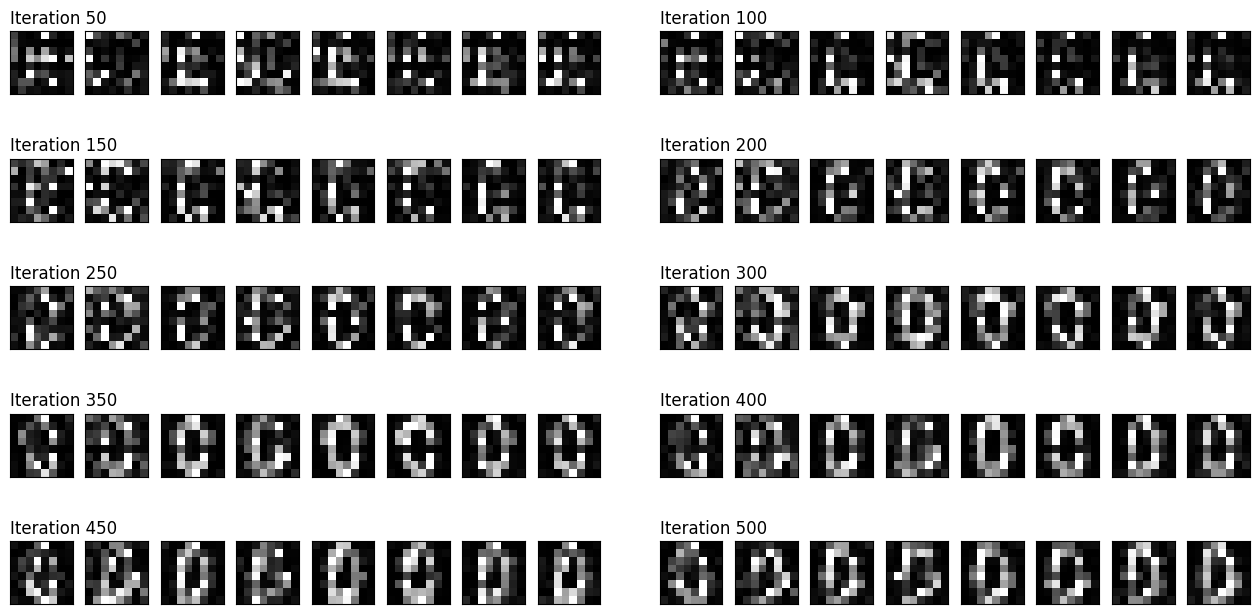

In [12]:
fig = plt.figure(figsize=(16, 8))
outer = gridspec.GridSpec(5, 2, wspace=0.1)

for i, images in enumerate(results):
    inner = gridspec.GridSpecFromSubplotSpec(1, images.size(0),
                    subplot_spec=outer[i])

    images = torch.squeeze(images, dim=1)
    for j, im in enumerate(images):

        ax = plt.Subplot(fig, inner[j])
        ax.imshow(im.numpy(), cmap="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        if j==0:
            ax.set_title(f'Iteration {50+i*50}', loc='left')
        fig.add_subplot(ax)

plt.show()

# 参考文献（References）

[1] Goodfellow I, Pouget-Abadie J, Mirza M, et al. Generative adversarial networks[J]. Communications of the ACM, 2020, 63(11): 139-144.

[2] Huang H L, Du Y, Gong M, et al. Experimental quantum generative adversarial networks for image generation[J]. Physical Review Applied, 2021, 16(2): 024051.